In [1]:
!pip install pandas numpy matplotlib seaborn scikit-learn openpyxl --quiet

In [3]:
# Import all libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    ConfusionMatrixDisplay
)

import warnings
warnings.filterwarnings('ignore')

# Make all charts look clean and consistent
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.spines.top']   = False
plt.rcParams['axes.spines.right'] = False
sns.set_palette('Set2')

print('✅ All libraries imported successfully!')

✅ All libraries imported successfully!


In [7]:
# ── UPDATE THIS PATH if your Excel file is in a different folder ──
FILE_PATH = r'C:\Users\lenovo\Downloads\Steve_EventData.xlsx'

# Load the User Engagement sheet
# skiprows=2 skips the description row and blank row at the top
df = pd.read_excel(FILE_PATH, sheet_name='4_User_Engagement', skiprows=2)

print(f'✅ Data loaded successfully!')
print(f'   Rows (users): {len(df)}')
print(f'   Columns:      {len(df.columns)}')
print(f'\nColumn names:')
print(df.columns.tolist())

✅ Data loaded successfully!
   Rows (users): 120
   Columns:      16

Column names:
['user_id', 'total_sessions', 'total_events', 'features_used', 'avg_session_duration_sec', 'last_active_date', 'first_active_date', 'plan', 'country', 'industry', 'signup_date', 'churned', 'churn_date', 'days_since_signup', 'days_since_last_active', 'avg_session_duration_min']


In [11]:
# Preview the first 5 rows
# This shows you what each row (user) looks like
df.head()

,user_id,total_sessions,total_events,features_used,avg_session_duration_sec,last_active_date,first_active_date,plan,country,industry,signup_date,churned,churn_date,days_since_signup,days_since_last_active,avg_session_duration_min
0,USR_0001,13,39,4,1988.794872,2026-01-18 13:12:58,2025-12-17 13:18:01,Solo,India,SaaS,2025-12-11,1,2026-01-20,71,32,33.1
1,USR_0002,100,286,5,1907.426573,2025-11-09 00:37:36,2025-11-08 00:06:00,Enterprise,Nigeria,AgriTech,2025-11-08,0,NaN,104,102,31.8
2,USR_0003,46,120,3,1984.091667,2025-11-03 00:32:21,2025-11-02 00:40:14,Enterprise,UK,FinTech,2025-11-02,0,NaN,110,108,33.1
3,USR_0004,87,244,5,1826.942623,2025-11-19 00:06:33,2025-11-18 00:20:40,Enterprise,India,FinTech,2025-11-18,0,NaN,94,92,30.4
4,USR_0005,60,148,6,1838.337838,2025-11-16 23:03:59,2025-11-16 00:27:48,Enterprise,Nigeria,AgriTech,2025-11-16,0,NaN,96,95,30.6


In [13]:
# Check data types and null values
# You want to make sure numeric columns are not stored as text
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 120 entries, 0 to 119
Data columns (total 16 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   user_id                   120 non-null    object 
 1   total_sessions            120 non-null    int64  
 2   total_events              120 non-null    int64  
 3   features_used             120 non-null    int64  
 4   avg_session_duration_sec  120 non-null    float64
 5   last_active_date          120 non-null    object 
 6   first_active_date         120 non-null    object 
 7   plan                      120 non-null    object 
 8   country                   120 non-null    object 
 9   industry                  120 non-null    object 
 10  signup_date               120 non-null    object 
 11  churned                   120 non-null    int64  
 12  churn_date                20 non-null     object 
 13  days_since_signup         120 non-null    int64  
 14  days_since

In [15]:
# Check for missing values in each column
print('Missing values per column:')
print(df.isnull().sum())

# Note: churn_date will have nulls for retained users — that is expected and correct

Missing values per column:
user_id                       0
total_sessions                0
total_events                  0
features_used                 0
avg_session_duration_sec      0
last_active_date              0
first_active_date             0
plan                          0
country                       0
industry                      0
signup_date                   0
churned                       0
churn_date                  100
days_since_signup             0
days_since_last_active        0
avg_session_duration_min      0
dtype: int64


In [17]:
# Check the churn distribution
# This tells you how many users churned vs stayed
churn_counts = df['churned'].value_counts()
churn_pct    = df['churned'].value_counts(normalize=True) * 100

print('Churn Distribution:')
print(f'  Retained (0): {churn_counts[0]} users  ({churn_pct[0]:.1f}%)')
print(f'  Churned  (1): {churn_counts[1]} users  ({churn_pct[1]:.1f}%)')
print(f'\n⚠️  Class imbalance ratio: {churn_counts[0]/churn_counts[1]:.1f}:1')
print('   → We will handle this with class_weight="balanced" in our models')

Churn Distribution:
  Retained (0): 100 users  (83.3%)
  Churned  (1): 20 users  (16.7%)

⚠️  Class imbalance ratio: 5.0:1
   → We will handle this with class_weight="balanced" in our models


In [19]:
# Summary statistics split by churn status
# Compare the averages for churned vs retained users
cols_to_compare = [
    'total_sessions', 'features_used',
    'avg_session_duration_min', 'days_since_last_active'
]

df.groupby('churned')[cols_to_compare].mean().round(2)

,total_sessions,features_used,avg_session_duration_min,days_since_last_active
churned,,,,
0,56.70,4.09,30.86,87.04
1,33.85,3.35,31.70,60.90


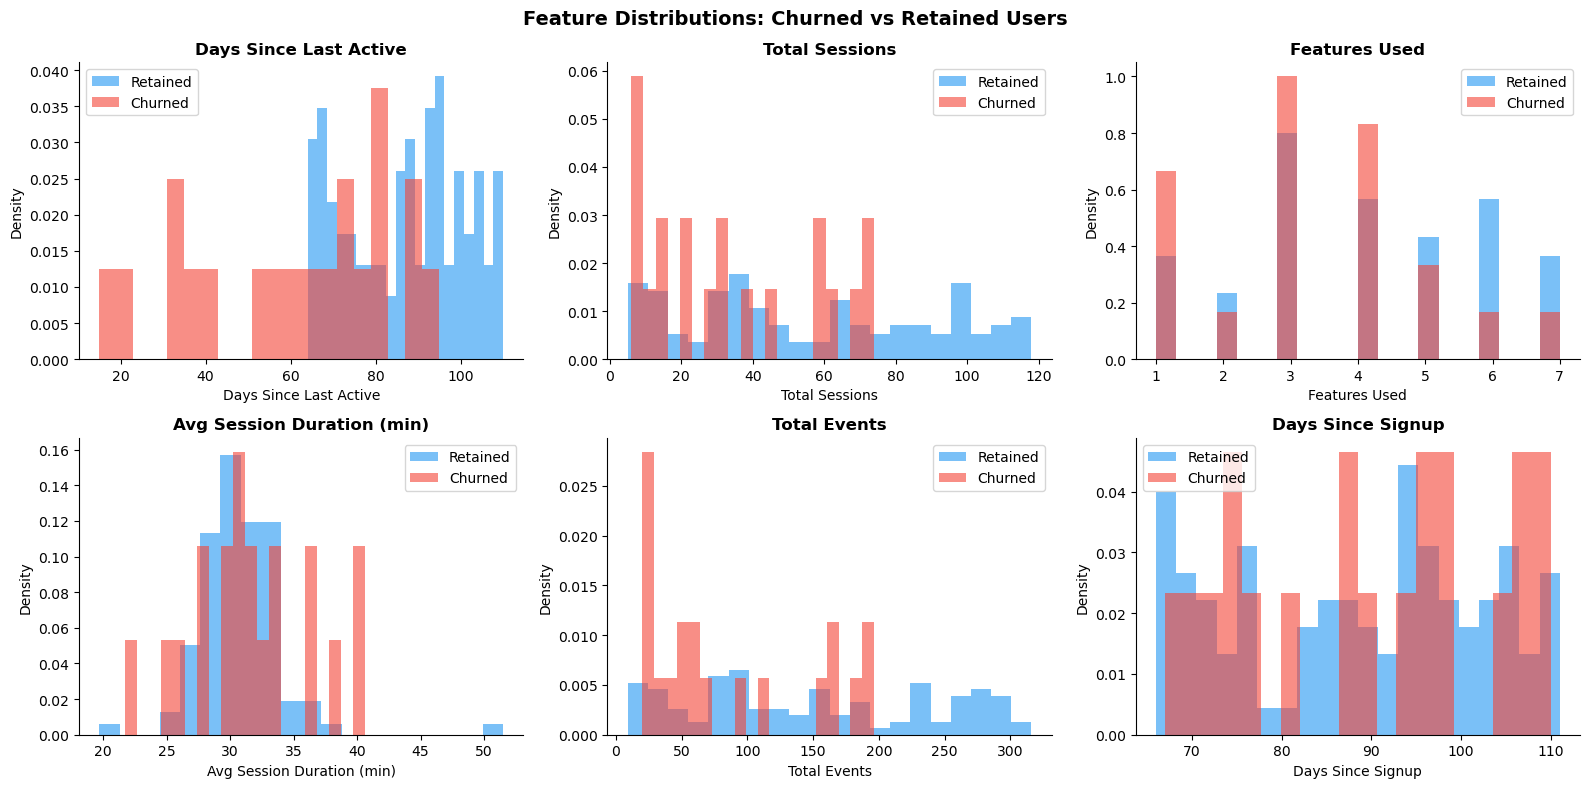

💡 Look for features where the blue and red bars are clearly separated — those are your best predictors!


In [21]:
# Plot: Distribution of key features — Churned vs Retained
# Each chart shows whether churned and retained users differ on that feature

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
fig.suptitle('Feature Distributions: Churned vs Retained Users', fontsize=14, fontweight='bold')

features_to_plot = [
    ('days_since_last_active',   'Days Since Last Active'),
    ('total_sessions',           'Total Sessions'),
    ('features_used',            'Features Used'),
    ('avg_session_duration_min', 'Avg Session Duration (min)'),
    ('total_events',             'Total Events'),
    ('days_since_signup',        'Days Since Signup'),
]

colors = {0: '#2196F3', 1: '#F44336'}  # Blue = Retained, Red = Churned

for ax, (col, title) in zip(axes.flat, features_to_plot):
    for churn_val, label in [(0, 'Retained'), (1, 'Churned')]:
        subset = df[df['churned'] == churn_val][col]
        ax.hist(subset, bins=20, alpha=0.6,
                color=colors[churn_val], label=label, density=True)
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel(title)
    ax.set_ylabel('Density')
    ax.legend()

plt.tight_layout()
plt.savefig('fig1_feature_distributions.png', dpi=150, bbox_inches='tight')
plt.show()
print('💡 Look for features where the blue and red bars are clearly separated — those are your best predictors!')

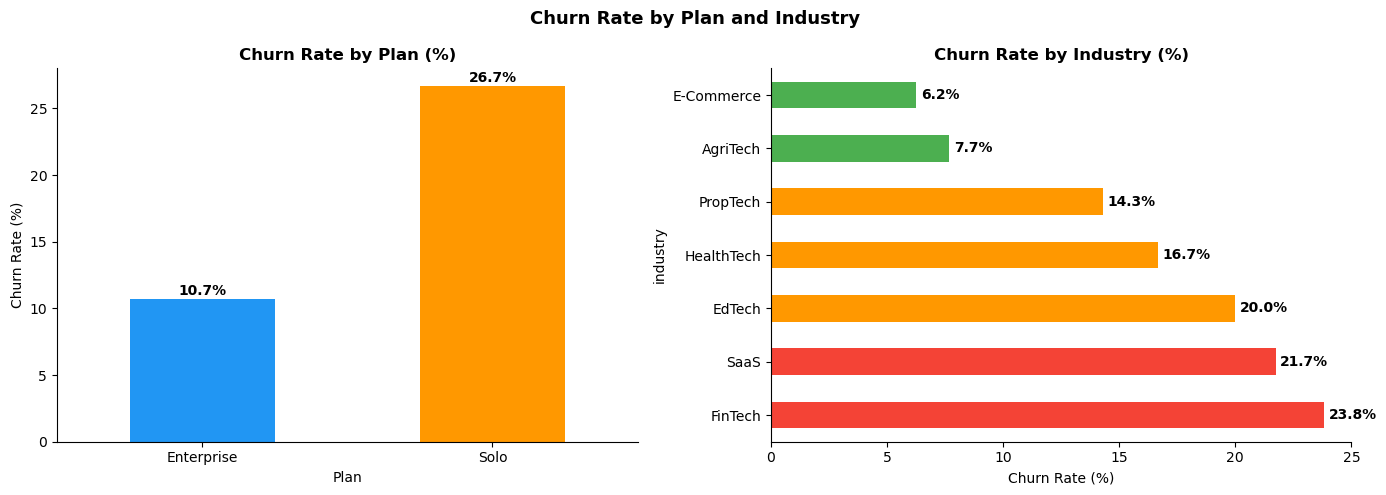

💡 Red bars = industries with highest churn. These users need most attention!


In [23]:
# Plot: Churn rate by Plan and by Industry

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Churn Rate by Plan and Industry', fontsize=13, fontweight='bold')

# Churn rate by Plan
plan_churn = df.groupby('plan')['churned'].mean() * 100
plan_churn.plot(kind='bar', ax=axes[0], color=['#2196F3','#FF9800'],
                edgecolor='none', width=0.5)
axes[0].set_title('Churn Rate by Plan (%)', fontweight='bold')
axes[0].set_xlabel('Plan')
axes[0].set_ylabel('Churn Rate (%)')
axes[0].tick_params(axis='x', rotation=0)
for i, v in enumerate(plan_churn):
    axes[0].text(i, v + 0.3, f'{v:.1f}%', ha='center', fontweight='bold')

# Churn rate by Industry
ind_churn = df.groupby('industry')['churned'].mean().sort_values(ascending=False) * 100
colors_ind = ['#F44336' if v > 20 else '#FF9800' if v > 10 else '#4CAF50' for v in ind_churn]
ind_churn.plot(kind='barh', ax=axes[1], color=colors_ind, edgecolor='none')
axes[1].set_title('Churn Rate by Industry (%)', fontweight='bold')
axes[1].set_xlabel('Churn Rate (%)')
for i, v in enumerate(ind_churn):
    axes[1].text(v + 0.2, i, f'{v:.1f}%', va='center', fontweight='bold')

plt.tight_layout()
plt.show()
print('💡 Red bars = industries with highest churn. These users need most attention!')

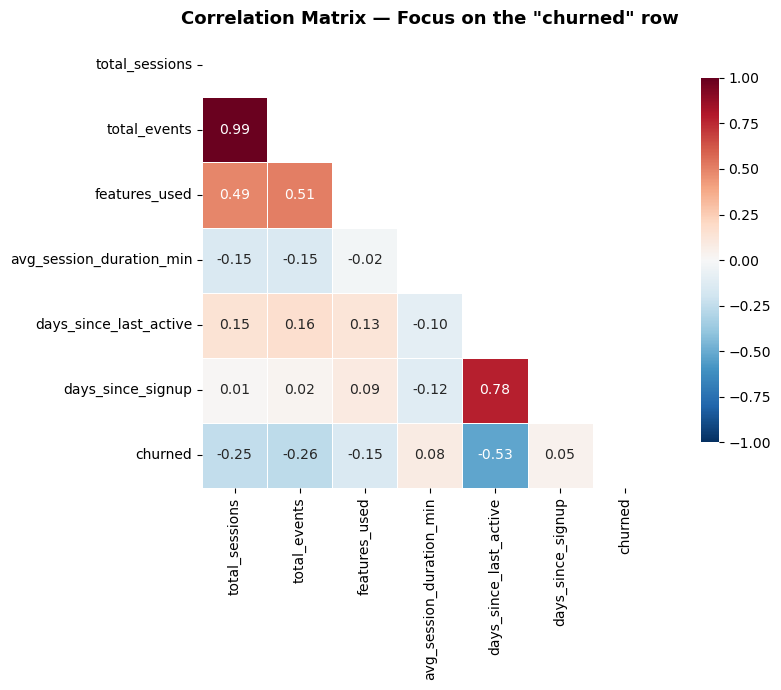


Correlation with churn (sorted):
days_since_last_active     -0.525868
total_events               -0.262904
total_sessions             -0.248727
features_used              -0.152611
days_since_signup           0.045534
avg_session_duration_min    0.084361
Name: churned, dtype: float64


In [25]:
# Correlation heatmap
# This shows how strongly each numeric feature correlates with churn
# Values close to -1 or +1 indicate stronger relationships

numeric_cols = [
    'total_sessions', 'total_events', 'features_used',
    'avg_session_duration_min', 'days_since_last_active',
    'days_since_signup', 'churned'
]

corr = df[numeric_cols].corr()

plt.figure(figsize=(10, 7))
mask = np.triu(np.ones_like(corr, dtype=bool))  # Hide upper triangle (it's a mirror)
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            vmin=-1, vmax=1, linewidths=0.5, square=True,
            cbar_kws={'shrink': 0.8})
plt.title('Correlation Matrix — Focus on the "churned" row', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Print churned correlations sorted
print('\nCorrelation with churn (sorted):')
print(corr['churned'].drop('churned').sort_values())

In [27]:
# Create a copy so we never modify the original data
df_model = df.copy()

# ── Feature 1: Events per Session ──
# Measures how deeply a user engages each time they log in
df_model['events_per_session'] = (
    df_model['total_events'] / df_model['total_sessions']
).round(2)

# ── Feature 2: Feature Breadth ──
# What proportion of Steve's 7 features has this user tried?
df_model['feature_breadth'] = (df_model['features_used'] / 7).round(3)

# ── Feature 3: Session Frequency ──
# How many sessions per day since they signed up?
# clip(lower=1) prevents division by zero for users who signed up today
df_model['session_frequency'] = (
    df_model['total_sessions'] / df_model['days_since_signup'].clip(lower=1)
).round(3)

# ── Feature 4: Recency Score ──
# 1 / (days_since_last_active + 1)
# A user active yesterday scores ~1.0; a user inactive for 100 days scores ~0.01
df_model['recency_score'] = (
    1 / (df_model['days_since_last_active'] + 1)
).round(4)

# ── Feature 5: Plan Encoded ──
# Machine learning models need numbers, not text
df_model['plan_encoded'] = (df_model['plan'] == 'Enterprise').astype(int)

# ── Feature 6: Industry Churn Risk ──
# Assign each user their industry's observed churn rate as a risk signal
industry_risk_map = {
    'FinTech':    0.238,
    'SaaS':       0.217,
    'EdTech':     0.200,
    'HealthTech': 0.167,
    'PropTech':   0.143,
    'AgriTech':   0.077,
    'E-Commerce': 0.062
}
df_model['industry_churn_risk'] = df_model['industry'].map(industry_risk_map)

# Preview the new features
new_features = [
    'user_id', 'plan', 'churned',
    'events_per_session', 'feature_breadth',
    'session_frequency', 'recency_score',
    'plan_encoded', 'industry_churn_risk'
]
print('✅ New features created:')
df_model[new_features].head(8)

✅ New features created:


,user_id,plan,churned,events_per_session,feature_breadth,session_frequency,recency_score,plan_encoded,industry_churn_risk
0,USR_0001,Solo,1,3.00,0.571,0.183,0.0303,0,0.217
1,USR_0002,Enterprise,0,2.86,0.714,0.962,0.0097,1,0.077
2,USR_0003,Enterprise,0,2.61,0.429,0.418,0.0092,1,0.238
3,USR_0004,Enterprise,0,2.80,0.714,0.926,0.0108,1,0.238
4,USR_0005,Enterprise,0,2.47,0.857,0.625,0.0104,1,0.077
5,USR_0006,Enterprise,0,2.82,1.000,0.814,0.0104,1,0.077
6,USR_0007,Solo,0,2.57,0.143,0.291,0.0097,0,0.167
7,USR_0008,Enterprise,0,2.52,0.714,0.590,0.0095,1,0.167


In [29]:
# Define the final list of features to use in the model
# These are our X (inputs) — the model will use these to predict churn

FEATURES = [
    'total_sessions',           # How many times did they log in?
    'features_used',            # How many of Steve's features did they use?
    'avg_session_duration_min', # How long per session?
    'days_since_last_active',   # How long since we last saw them?
    'days_since_signup',        # How long have they been a user?
    'events_per_session',       # How deeply do they engage each session?
    'feature_breadth',          # What % of the platform did they explore?
    'session_frequency',        # How consistently do they come back?
    'recency_score',            # Are they recently active?
    'plan_encoded',             # Enterprise or Solo?
    'industry_churn_risk',      # What is their industry's historical churn rate?
]

# X = features (inputs), y = target (what we want to predict)
X = df_model[FEATURES]
y = df_model['churned']

print(f'✅ Feature matrix ready')
print(f'   X shape: {X.shape}  (rows=users, columns=features)')
print(f'   y shape: {y.shape}  (churn label for each user)')
print(f'   Churned: {y.sum()} | Retained: {(y==0).sum()}')

✅ Feature matrix ready
   X shape: (120, 11)  (rows=users, columns=features)
   y shape: (120,)  (churn label for each user)
   Churned: 20 | Retained: 100


In [31]:
# ── Train/Test Split ──
# test_size=0.25 → 25% held out for testing
# stratify=y     → preserves churn ratio in both splits
# random_state   → makes results reproducible (same split every time you run)

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

print('✅ Data split complete')
print(f'   Training set: {len(X_train)} users | Churn rate: {y_train.mean()*100:.1f}%')
print(f'   Test set:     {len(X_test)} users  | Churn rate: {y_test.mean()*100:.1f}%')
print('   ✓ Churn rates are equal — stratification worked!')

✅ Data split complete
   Training set: 90 users | Churn rate: 16.7%
   Test set:     30 users  | Churn rate: 16.7%
   ✓ Churn rates are equal — stratification worked!


In [33]:
# ── Feature Scaling ──
# StandardScaler transforms each feature to have mean=0 and std=1
# IMPORTANT: fit on TRAIN only, then transform BOTH train and test
# (fitting on test would leak information from the test set)

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)   # fit + transform
X_test_scaled  = scaler.transform(X_test)         # transform only (no fit!)

print('✅ Features scaled')
print(f'   Before scaling — total_sessions mean: {X_train["total_sessions"].mean():.1f}')
print(f'   After scaling  — total_sessions mean: {X_train_scaled[:, 0].mean():.4f} (≈ 0)')
print()
print('💡 Note: Scaled data is only needed for Logistic Regression.')
print('   Random Forest and Gradient Boosting do not need scaling.')

✅ Features scaled
   Before scaling — total_sessions mean: 52.9
   After scaling  — total_sessions mean: -0.0000 (≈ 0)

💡 Note: Scaled data is only needed for Logistic Regression.
   Random Forest and Gradient Boosting do not need scaling.


In [35]:
# ── Model 1: Logistic Regression ──
# Uses scaled features
# class_weight='balanced' adjusts for the imbalanced dataset

lr_model = LogisticRegression(
    random_state=42,
    max_iter=1000,
    class_weight='balanced'
)
lr_model.fit(X_train_scaled, y_train)
print('✅ Logistic Regression trained')

✅ Logistic Regression trained


In [37]:
# ── Model 2: Random Forest ──
# Uses raw (unscaled) features — trees don't need scaling
# n_estimators=100 → builds 100 decision trees and averages them

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight='balanced'
)
rf_model.fit(X_train, y_train)
print('✅ Random Forest trained')

✅ Random Forest trained


In [39]:
# ── Model 3: Gradient Boosting ──
# Uses raw features
# Builds trees sequentially — each tree corrects errors from the previous one
# learning_rate=0.1 controls how much each tree contributes

gb_model = GradientBoostingClassifier(
    n_estimators=100,
    random_state=42,
    learning_rate=0.1
)
gb_model.fit(X_train, y_train)
print('✅ Gradient Boosting trained')

✅ Gradient Boosting trained


In [41]:
# Generate predictions for all three models

# Logistic Regression uses scaled test data
lr_pred  = lr_model.predict(X_test_scaled)
lr_proba = lr_model.predict_proba(X_test_scaled)[:, 1]  # probability of churn

# Random Forest and Gradient Boosting use raw test data
rf_pred  = rf_model.predict(X_test)
rf_proba = rf_model.predict_proba(X_test)[:, 1]

gb_pred  = gb_model.predict(X_test)
gb_proba = gb_model.predict_proba(X_test)[:, 1]

# Print AUC scores for quick comparison
print('ROC-AUC Scores (higher = better, max = 1.0):')
print(f'  Logistic Regression : {roc_auc_score(y_test, lr_proba):.3f}')
print(f'  Random Forest       : {roc_auc_score(y_test, rf_proba):.3f}')
print(f'  Gradient Boosting   : {roc_auc_score(y_test, gb_proba):.3f}')

ROC-AUC Scores (higher = better, max = 1.0):
  Logistic Regression : 0.984
  Random Forest       : 0.796
  Gradient Boosting   : 0.864


In [43]:
# Detailed classification reports for each model
# Focus on the row labelled '1' — that is the churn class

print('=' * 50)
print('LOGISTIC REGRESSION')
print('=' * 50)
print(classification_report(y_test, lr_pred, target_names=['Retained','Churned']))

print('=' * 50)
print('RANDOM FOREST')
print('=' * 50)
print(classification_report(y_test, rf_pred, target_names=['Retained','Churned']))

print('=' * 50)
print('GRADIENT BOOSTING')
print('=' * 50)
print(classification_report(y_test, gb_pred, target_names=['Retained','Churned']))

LOGISTIC REGRESSION
              precision    recall  f1-score   support

    Retained       0.96      0.96      0.96        25
     Churned       0.80      0.80      0.80         5

    accuracy                           0.93        30
   macro avg       0.88      0.88      0.88        30
weighted avg       0.93      0.93      0.93        30

RANDOM FOREST
              precision    recall  f1-score   support

    Retained       0.86      1.00      0.93        25
     Churned       1.00      0.20      0.33         5

    accuracy                           0.87        30
   macro avg       0.93      0.60      0.63        30
weighted avg       0.89      0.87      0.83        30

GRADIENT BOOSTING
              precision    recall  f1-score   support

    Retained       0.96      1.00      0.98        25
     Churned       1.00      0.80      0.89         5

    accuracy                           0.97        30
   macro avg       0.98      0.90      0.93        30
weighted avg       0.9

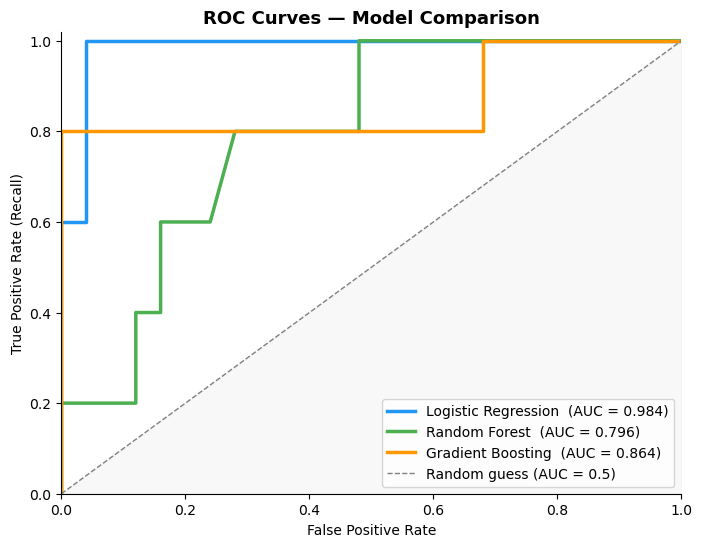

In [45]:
# Plot: ROC Curves for all three models on the same chart
# The curve shows the trade-off between catching churners (recall)
# and avoiding false alarms (1 - specificity)
# A model hugging the top-left corner is ideal

plt.figure(figsize=(8, 6))

models_to_plot = [
    ('Logistic Regression', lr_proba, '#2196F3'),
    ('Random Forest',       rf_proba, '#4CAF50'),
    ('Gradient Boosting',   gb_proba, '#FF9800'),
]

for name, proba, color in models_to_plot:
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc = roc_auc_score(y_test, proba)
    plt.plot(fpr, tpr, lw=2.5, color=color, label=f'{name}  (AUC = {auc:.3f})')

plt.plot([0, 1], [0, 1], '--', color='gray', lw=1, label='Random guess (AUC = 0.5)')
plt.fill_between([0,1],[0,1], alpha=0.05, color='gray')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate (Recall)')
plt.title('ROC Curves — Model Comparison', fontsize=13, fontweight='bold')
plt.legend(loc='lower right')
plt.xlim(0, 1); plt.ylim(0, 1.02)
plt.savefig('fig2_roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()

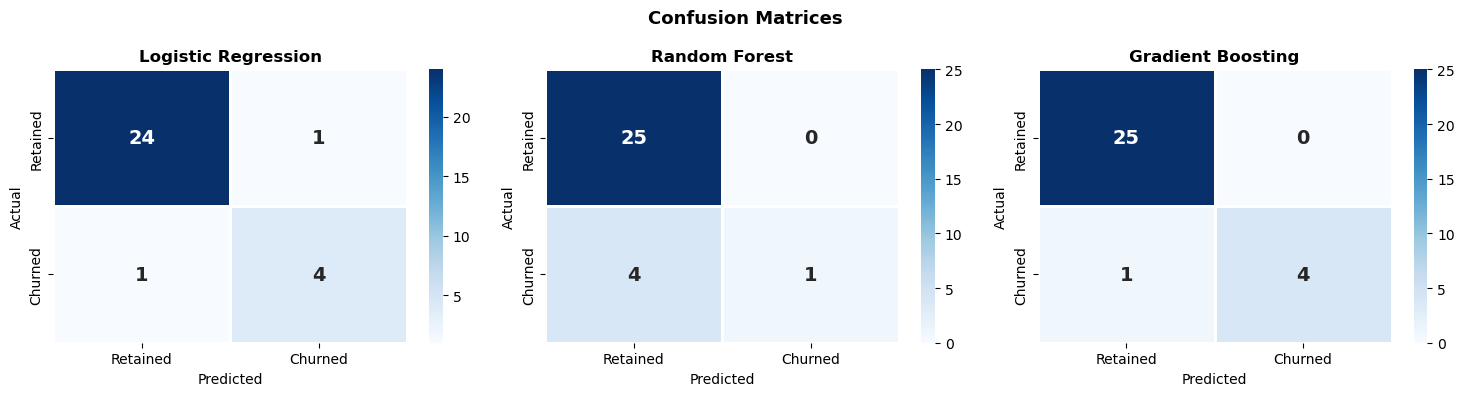

💡 Bottom-right cell = users the model correctly identified as churners (True Positives)
   Bottom-left cell  = churners the model missed (False Negatives) — you want this LOW


In [47]:
# Plot: Confusion Matrices
# The matrix shows exactly what each model predicted vs what was actually true
#
#              Predicted Retained | Predicted Churned
# Actual Retained [True Negative]   [False Positive]  ← false alarm
# Actual Churned  [False Negative]  [True Positive]   ← caught a churner
#
# For churn, we want high True Positives and low False Negatives

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('Confusion Matrices', fontsize=13, fontweight='bold')

models_cm = [
    ('Logistic Regression', lr_pred),
    ('Random Forest',       rf_pred),
    ('Gradient Boosting',   gb_pred),
]

for ax, (name, pred) in zip(axes, models_cm):
    cm = confusion_matrix(y_test, pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Retained','Churned'],
                yticklabels=['Retained','Churned'],
                linewidths=1, annot_kws={'size': 14, 'weight': 'bold'})
    ax.set_title(name, fontweight='bold')
    ax.set_ylabel('Actual')
    ax.set_xlabel('Predicted')

plt.tight_layout()
plt.savefig('fig3_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()
print('💡 Bottom-right cell = users the model correctly identified as churners (True Positives)')
print('   Bottom-left cell  = churners the model missed (False Negatives) — you want this LOW')

In [49]:
# Cross-Validation — more reliable than a single train/test split
# Splits data into 5 folds, trains on 4, tests on 1, repeats 5 times
# Gives you a mean AUC with uncertainty range

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print('5-Fold Cross-Validation AUC Scores:')
print('-' * 40)

cv_models = [
    ('Logistic Regression', lr_model, X_train_scaled),
    ('Random Forest',       rf_model, X_train),
    ('Gradient Boosting',   gb_model, X_train),
]

for name, model, X_tr in cv_models:
    scores = cross_val_score(model, X_tr, y_train, cv=cv, scoring='roc_auc')
    print(f'{name}')
    print(f'  Fold scores: {[round(s,3) for s in scores]}')
    print(f'  Mean: {scores.mean():.3f}  |  Std: {scores.std():.3f}')
    print()

5-Fold Cross-Validation AUC Scores:
----------------------------------------
Logistic Regression
  Fold scores: [1.0, 0.822, 1.0, 1.0, 1.0]
  Mean: 0.964  |  Std: 0.071

Random Forest
  Fold scores: [1.0, 0.844, 0.933, 0.978, 1.0]
  Mean: 0.951  |  Std: 0.059

Gradient Boosting
  Fold scores: [1.0, 0.889, 1.0, 0.933, 0.978]
  Mean: 0.960  |  Std: 0.043



In [51]:
# Feature Importance from Random Forest
importance_df = pd.DataFrame({
    'feature':    FEATURES,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False)

print('Feature Importance (Random Forest):')
print(importance_df.to_string(index=False))

Feature Importance (Random Forest):
                 feature  importance
  days_since_last_active    0.231617
           recency_score    0.213037
       session_frequency    0.140552
       days_since_signup    0.115499
     industry_churn_risk    0.074555
          total_sessions    0.072104
avg_session_duration_min    0.058204
      events_per_session    0.055057
         feature_breadth    0.020098
           features_used    0.013394
            plan_encoded    0.005883


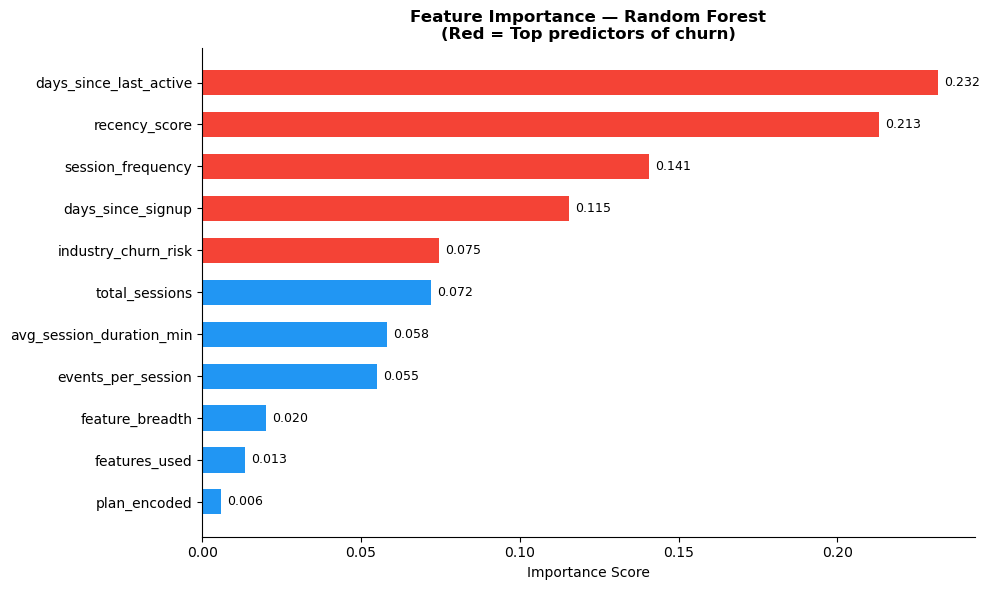

💡 Share this chart with Walturn's product team — it tells them exactly what to fix!


In [53]:
# Plot: Feature Importance
# Bars in red = top predictors. These are the key churn signals for Walturn.

importance_sorted = importance_df.sort_values('importance')
top_threshold = importance_sorted['importance'].quantile(0.6)
bar_colors = [
    '#F44336' if v >= top_threshold else '#2196F3'
    for v in importance_sorted['importance']
]

plt.figure(figsize=(10, 6))
bars = plt.barh(importance_sorted['feature'], importance_sorted['importance'],
                color=bar_colors, edgecolor='none', height=0.6)

for bar, val in zip(bars, importance_sorted['importance']):
    plt.text(val + 0.002, bar.get_y() + bar.get_height()/2,
             f'{val:.3f}', va='center', fontsize=9)

plt.xlabel('Importance Score')
plt.title('Feature Importance — Random Forest\n(Red = Top predictors of churn)',
          fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('fig4_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print('💡 Share this chart with Walturn\'s product team — it tells them exactly what to fix!')

In [55]:
# Print key product insights based on feature importance

top3 = importance_df.head(3)

print('=' * 55)
print('KEY PRODUCT INSIGHTS FROM FEATURE IMPORTANCE')
print('=' * 55)

insights = {
    'days_since_last_active': '→ Users who go quiet quickly are your biggest churn risk. Consider re-engagement emails after 14 days of inactivity.',
    'recency_score':           '→ Recency is everything. A user active this week is far less likely to churn than one inactive for a month.',
    'session_frequency':       '→ Consistent usage = strong retention. Onboarding flows should target a habit of at least 2 sessions/week.',
    'total_sessions':          '→ More sessions = lower churn. Early activation (first 7 days) is critical.',
    'feature_breadth':         '→ Users who explore more features churn less. Consider in-app prompts to try underused features.',
    'features_used':           '→ Multi-feature users are stickier. Cross-feature discovery is a retention lever.',
    'plan_encoded':             '→ Enterprise users churn less. Solo users need more guided value delivery.',
    'industry_churn_risk':     '→ FinTech and SaaS users need extra attention. Industry-specific onboarding could help.',
    'events_per_session':      '→ Depth of engagement per session signals commitment.',
    'avg_session_duration_min':'→ Longer sessions indicate users finding value. Short sessions may signal confusion.',
    'days_since_signup':       '→ New users are most vulnerable. A strong first-30-days experience is critical.',
}

for i, row in top3.iterrows():
    feat = row['feature']
    imp  = row['importance']
    print(f'\n#{list(importance_df["feature"]).index(feat)+1}. {feat.upper()}  (importance: {imp:.3f})')
    print(insights.get(feat, ''))

print('\n' + '=' * 55)

KEY PRODUCT INSIGHTS FROM FEATURE IMPORTANCE

#1. DAYS_SINCE_LAST_ACTIVE  (importance: 0.232)
→ Users who go quiet quickly are your biggest churn risk. Consider re-engagement emails after 14 days of inactivity.

#2. RECENCY_SCORE  (importance: 0.213)
→ Recency is everything. A user active this week is far less likely to churn than one inactive for a month.

#3. SESSION_FREQUENCY  (importance: 0.141)
→ Consistent usage = strong retention. Onboarding flows should target a habit of at least 2 sessions/week.



In [57]:
# Score ALL 120 users using the Random Forest model
# (Random Forest is used here for its reliable probability calibration)

all_proba = rf_model.predict_proba(X)[:, 1]

# Build the at-risk report DataFrame
risk_report = df_model[[
    'user_id', 'plan', 'country', 'industry',
    'total_sessions', 'features_used',
    'avg_session_duration_min', 'days_since_last_active',
    'churned'
]].copy()

risk_report['churn_probability_%'] = (all_proba * 100).round(1)

# Assign risk tier
risk_report['risk_tier'] = pd.cut(
    all_proba,
    bins=[0, 0.3, 0.5, 0.7, 1.0],
    labels=['Low', 'Medium', 'High', 'Critical']
)

# Sort by churn probability, highest first
risk_report = risk_report.sort_values('churn_probability_%', ascending=False).reset_index(drop=True)

# Preview the top 15 highest-risk users
print('Top 15 Highest-Risk Users:')
risk_report.head(15)

Top 15 Highest-Risk Users:


,user_id,plan,country,industry,total_sessions,features_used,avg_session_duration_min,days_since_last_active,churned,churn_probability_%,risk_tier
0,USR_0083,Enterprise,UK,HealthTech,30,4,25.5,15,1,96.0,Critical
1,USR_0056,Solo,Canada,HealthTech,22,4,36.5,21,1,94.0,Critical
2,USR_0067,Enterprise,India,SaaS,69,5,31.9,42,1,94.0,Critical
3,USR_0020,Solo,USA,EdTech,9,3,21.7,36,1,92.0,Critical
4,USR_0001,Solo,India,SaaS,13,4,33.1,32,1,89.0,Critical
5,USR_0031,Solo,UK,PropTech,6,1,30.2,32,1,88.0,Critical
6,USR_0074,Solo,India,SaaS,9,2,40.6,58,1,87.0,Critical
7,USR_0044,Enterprise,Nigeria,FinTech,63,3,30.7,59,1,87.0,Critical
8,USR_0015,Enterprise,India,FinTech,59,7,30.4,80,1,84.0,Critical
9,USR_0071,Enterprise,Canada,FinTech,74,6,30.7,90,1,78.0,Critical


In [59]:
# Risk tier summary
tier_summary = risk_report.groupby('risk_tier', observed=True).agg(
    users=('user_id', 'count'),
    avg_churn_prob=('churn_probability_%', 'mean'),
    actually_churned=('churned', 'sum')
).round(1)

print('Risk Tier Summary:')
print(tier_summary)

print(f'\n⚠️  Critical risk users: {len(risk_report[risk_report["risk_tier"]=="Critical"])}')
print(f'   High risk users:     {len(risk_report[risk_report["risk_tier"]=="High"])}')
print(f'   Medium risk users:   {len(risk_report[risk_report["risk_tier"]=="Medium"])}')
print(f'   Low risk users:      {len(risk_report[risk_report["risk_tier"]=="Low"])}')

Risk Tier Summary:
           users  avg_churn_prob  actually_churned
risk_tier                                         
Low           84             5.2                 4
Medium         3            34.3                 0
High           2            67.0                 2
Critical      14            84.7                14

⚠️  Critical risk users: 14
   High risk users:     2
   Medium risk users:   3
   Low risk users:      84


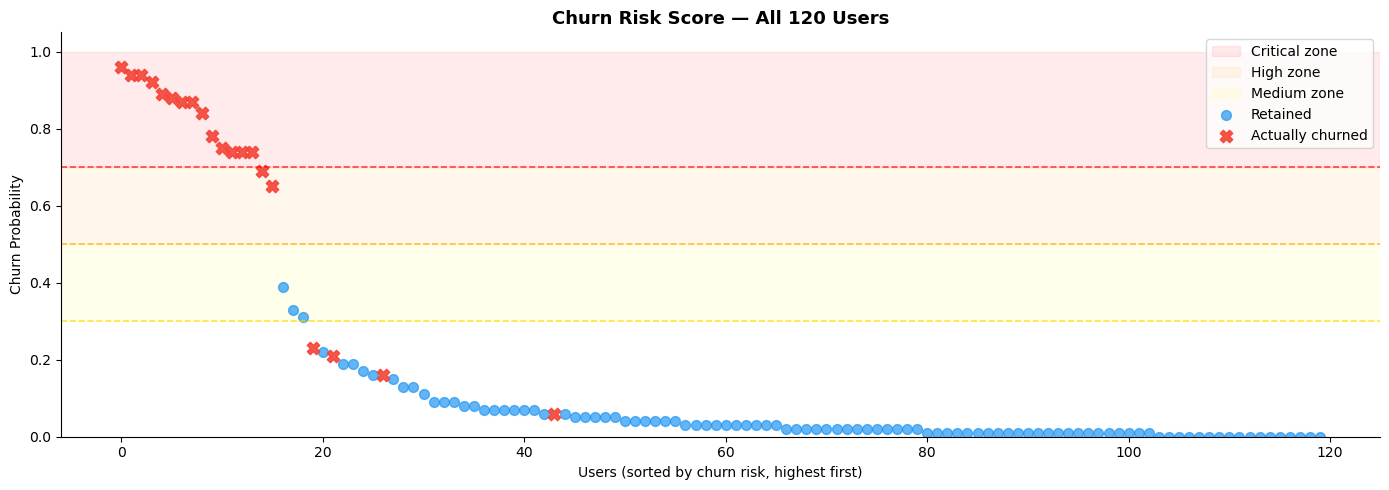

💡 Red X marks that sit in the blue/low zone = missed churners (model underestimated their risk)
   Blue dots in the red zone = false alarms (model overestimated risk)


In [61]:
# Plot: Churn Probability for all 120 users
# Each dot is a user, sorted by risk score
# Red X marks = users who actually churned

plt.figure(figsize=(14, 5))

# Background zones
plt.axhspan(0.70, 1.00, alpha=0.08, color='red',    label='Critical zone')
plt.axhspan(0.50, 0.70, alpha=0.08, color='orange', label='High zone')
plt.axhspan(0.30, 0.50, alpha=0.08, color='yellow', label='Medium zone')

# All users
retained_mask = risk_report['churned'] == 0
churned_mask  = risk_report['churned'] == 1

plt.scatter(risk_report[retained_mask].index,
            risk_report[retained_mask]['churn_probability_%'] / 100,
            color='#2196F3', s=50, alpha=0.7, label='Retained')

plt.scatter(risk_report[churned_mask].index,
            risk_report[churned_mask]['churn_probability_%'] / 100,
            color='#F44336', s=80, marker='X', alpha=0.9, label='Actually churned')

# Threshold lines
plt.axhline(0.70, color='red',    linestyle='--', lw=1.2, alpha=0.7)
plt.axhline(0.50, color='orange', linestyle='--', lw=1.2, alpha=0.7)
plt.axhline(0.30, color='gold',   linestyle='--', lw=1.2, alpha=0.7)

plt.xlabel('Users (sorted by churn risk, highest first)')
plt.ylabel('Churn Probability')
plt.title('Churn Risk Score — All 120 Users', fontsize=13, fontweight='bold')
plt.legend(loc='upper right')
plt.ylim(0, 1.05)
plt.tight_layout()
plt.savefig('fig5_churn_risk_all_users.png', dpi=150, bbox_inches='tight')
plt.show()
print('💡 Red X marks that sit in the blue/low zone = missed churners (model underestimated their risk)')
print('   Blue dots in the red zone = false alarms (model overestimated risk)')

In [63]:
# Export the at-risk report to Excel
# This is what you would send to the customer success team every Monday morning

output_file = 'Steve_Weekly_AtRisk_Report.xlsx'

with pd.ExcelWriter(output_file, engine='openpyxl') as writer:
    # Sheet 1: Full ranked risk list
    risk_report.to_excel(writer, sheet_name='All Users — Ranked by Risk', index=False)

    # Sheet 2: Critical + High risk only
    urgent = risk_report[risk_report['risk_tier'].isin(['Critical', 'High'])]
    urgent.to_excel(writer, sheet_name='Urgent Action Required', index=False)

    # Sheet 3: Model performance summary
    summary = pd.DataFrame({
        'Model': ['Logistic Regression', 'Random Forest', 'Gradient Boosting'],
        'ROC-AUC': [
            round(roc_auc_score(y_test, lr_proba), 3),
            round(roc_auc_score(y_test, rf_proba), 3),
            round(roc_auc_score(y_test, gb_proba), 3),
        ]
    })
    summary.to_excel(writer, sheet_name='Model Performance', index=False)

print(f'✅ Report saved to: {output_file}')
print(f'   Sheet 1: All 120 users ranked by churn risk')
print(f'   Sheet 2: {len(urgent)} users needing urgent action')
print(f'   Sheet 3: Model performance summary')

✅ Report saved to: Steve_Weekly_AtRisk_Report.xlsx
   Sheet 1: All 120 users ranked by churn risk
   Sheet 2: 16 users needing urgent action
   Sheet 3: Model performance summary


In [65]:
# Final project summary

best_auc   = max(roc_auc_score(y_test, lr_proba),
                 roc_auc_score(y_test, rf_proba),
                 roc_auc_score(y_test, gb_proba))
best_model_name = ['Logistic Regression','Random Forest','Gradient Boosting'][
    [roc_auc_score(y_test, lr_proba),
     roc_auc_score(y_test, rf_proba),
     roc_auc_score(y_test, gb_proba)].index(best_auc)
]

top_feature = importance_df.iloc[0]['feature']
critical_count = len(risk_report[risk_report['risk_tier'] == 'Critical'])

print('=' * 58)
print('  PHASE 3 COMPLETE — CHURN MODEL SUMMARY')
print('=' * 58)
print(f'  Dataset          : 120 users | 16.7% churn rate')
print(f'  Features built   : {len(FEATURES)} behavioral features')
print(f'  Models trained   : Logistic Regression, Random Forest,')
print(f'                     Gradient Boosting')
print(f'  Best model       : {best_model_name} (AUC = {best_auc:.3f})')
print(f'  Top churn signal : {top_feature}')
print(f'  Critical users   : {critical_count} need immediate outreach')
print()
print('  Files saved:')
print('    fig1_feature_distributions.png')
print('    fig2_roc_curves.png')
print('    fig3_confusion_matrices.png')
print('    fig4_feature_importance.png')
print('    fig5_churn_risk_all_users.png')
print('    Steve_Weekly_AtRisk_Report.xlsx')
print()
print('  Next steps (Phase 4):')
print('    1. Write up findings in a report')
print('    2. Present to Walturn stakeholders')
print('    3. Hand off the weekly report pipeline')
print('    4. Document the code for maintainability')
print('=' * 58)

  PHASE 3 COMPLETE — CHURN MODEL SUMMARY
  Dataset          : 120 users | 16.7% churn rate
  Features built   : 11 behavioral features
  Models trained   : Logistic Regression, Random Forest,
                     Gradient Boosting
  Best model       : Logistic Regression (AUC = 0.984)
  Top churn signal : days_since_last_active
  Critical users   : 14 need immediate outreach

  Files saved:
    fig1_feature_distributions.png
    fig2_roc_curves.png
    fig3_confusion_matrices.png
    fig4_feature_importance.png
    fig5_churn_risk_all_users.png
    Steve_Weekly_AtRisk_Report.xlsx

  Next steps (Phase 4):
    1. Write up findings in a report
    2. Present to Walturn stakeholders
    3. Hand off the weekly report pipeline
    4. Document the code for maintainability
